In [98]:
import pandas as pd

In [99]:
results_df =  pd.read_csv('C:\\Users\Ronza\Dev\DP-MSD\\amazon\\results\\results_from_server\Amazon_Matroid_Results.csv')

In [100]:
results_df.head()

,alg,k,eps,private,lambda_param,gamma,rep,value,relevance,diversity,queries,time_sec,timestamp
0,RandomBaseline,4,0.2,True,0.1,0.2,0,0.031710,0.008356,0.241898,0,0.0028,1771531180486
1,LocalSearch_Matroid,4,0.2,True,0.1,0.2,0,0.111293,0.086032,0.338642,305117,137.7778,1771531318264
2,DPSampleLocalSearch,4,0.2,True,0.1,0.2,0,0.111293,0.086032,0.338642,22902,115.6153,1771531433879
3,DPLocalSearch,4,0.2,True,0.1,0.2,0,0.111293,0.086032,0.338642,22907,115.9538,1771531549833
4,RandomBaseline,4,0.2,True,0.1,0.2,1,0.030726,0.007865,0.236470,0,0.0025,1771531549836


# Amazon Matroid


## Impact of k on score


In [101]:
results_df['alg'] = results_df['alg'].replace(
    {
        'LocalSearch_Matroid': 'LS',
        'DPSampleLocalSearch': 'DP-SLS',
        'RandomBaseline': 'Random'
    }
)
results_df = results_df[results_df['alg'].isin(['LS', 'DP-SLS', 'Random'])]

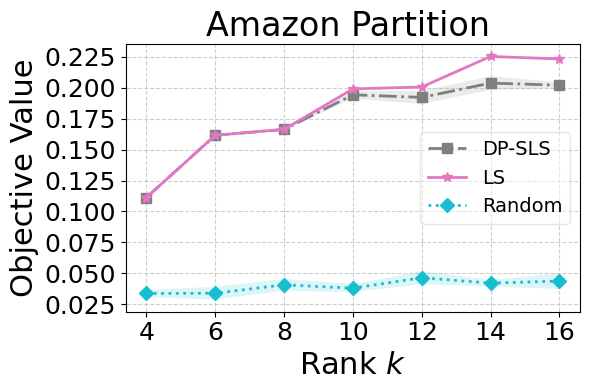

In [108]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data for eps=0.1 and lambda_param=0.1
# Using your initial filtering requirements
filtered_df = results_df[(results_df['eps'] == 0.2) & (results_df['lambda_param'] == 0.1)]

# 2. Group by algorithm and 'k' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'k'])['value'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with large text and distinct styles
plt.figure(figsize=(6, 4)) # Large figure size for clarity

# Define specific styles to ensure variety across algorithms
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-.', '-', ':', '-.', '-', '--']
colors = ['#7f7f7f','#e377c2','#17becf']
# Get the list of algorithms present in the stats
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    # Assign a unique combination of color, marker, and linestyle to each alg
    line, = plt.plot(
    alg_data['k'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
    )
    plt.fill_between(
    alg_data['k'], 
    alg_data['mean'] - alg_data['std'], 
    alg_data['mean'] + alg_data['std'], 
    color=line.get_color(),
    alpha=0.15,  # Low alpha for transparency
    edgecolor='none' # No border around the shade for a softer look
     )
    # plt.errorbar(
    #     alg_data['k'], 
    #     alg_data['mean'], 
    #     yerr=alg_data['std'], 
    #     label=alg,
    #     color=colors[i % len(colors)],
    #     marker=markers[i % len(markers)],
    #     linestyle=linestyles[i % len(linestyles)],
    #     linewidth=2.5,  # Slightly thicker lines
    #     markersize=6,  # Larger markers for better visibility
    #     capsize=6       # Distinct caps for the error bars
    # )

# Formatting for large text relative to the image size
plt.xlabel('Rank $k$', fontsize=22)
plt.ylabel('Objective Value', fontsize=22)
plt.title('Amazon-Partition ', fontsize=24)

plt.xticks(range(4,18,2), fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5)# Legend with a box for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('amazon_matroid_k_on_val.pdf')
plt.show()

## Impact of eps on score


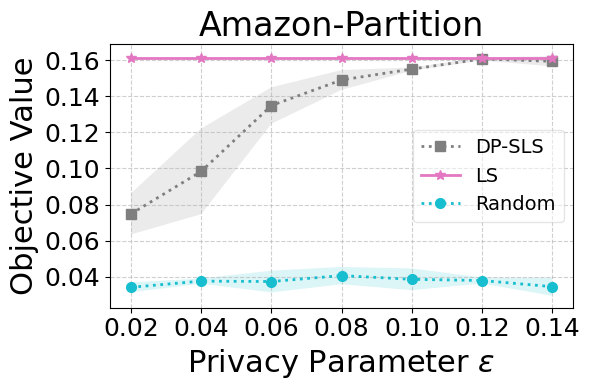

In [111]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Filter the data for k=15 and lambda_param=0.1
target_k = 6
eps_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
eps_list = [0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14]

filtered_df = results_df[
    (results_df['k'] == target_k) & 
    (results_df['lambda_param'] == 0.1) & 
    (results_df['eps'].round(2).isin(eps_list)) 
]

# 2. Group by algorithm and 'eps' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'eps'])['value'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with your exact requested sizes
plt.figure(figsize=(6, 4)) # Exact size from your reference

# Define specific styles
markers = ['s', '*', 'o', '^', 'o', 'x']
linestyles = [':', '-', ':', '-.', '-', '--']
colors = ['#7f7f7f','#e377c2','#17becf']
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    # plt.errorbar(
    #     alg_data['eps'], 
    #     alg_data['mean'], 
    #     yerr=alg_data['std'], 
    #     label=alg,
    #     color=colors[i % len(colors)],
    #     marker=markers[i % len(markers)],
    #     linestyle=linestyles[i % len(linestyles)],
    #     linewidth=2.5,  
    #     markersize=6,   # Exact size from your reference
    #     capsize=6       
    # )
    line, = plt.plot(
    alg_data['eps'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
    )
    plt.fill_between(
    alg_data['eps'], 
    alg_data['mean'] - alg_data['std'], 
    alg_data['mean'] + alg_data['std'], 
    color=line.get_color(),
    alpha=0.15,  # Low alpha for transparency
    edgecolor='none' # No border around the shade for a softer look
     )

# Formatting with exact fontsizes from your reference
plt.xlabel('Privacy Parameter $\\varepsilon$', fontsize=22)
plt.ylabel('Objective Value', fontsize=22)
plt.title('Amazon-Partition', fontsize=24)

# Show only even ticks to avoid crowding: 0.02, 0.04, 0.06, 0.08, 0.10
plt.xticks(eps_list, fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5)# Exact size from your reference
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() 
plt.savefig('amazon_matroid_eps_on_val.pdf')
plt.show()

## Impact of k on num queries

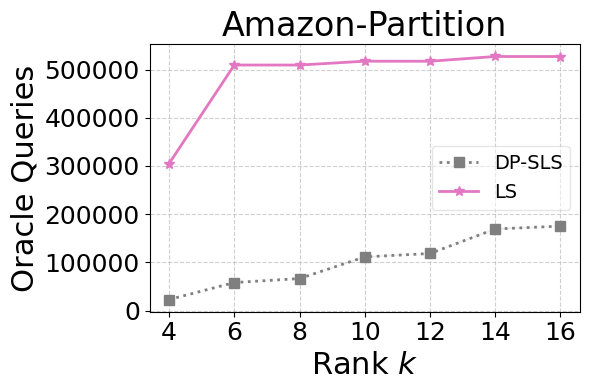

In [113]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data for eps=0.1 and lambda_param=0.1
# Using your initial filtering requirements
filtered_df = results_df[(results_df['eps'] == 0.2) & (results_df['lambda_param'] == 0.1) & ~results_df['alg'].isin(['Random'])]

# 2. Group by algorithm and 'k' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'k'])['queries'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with large text and distinct styles
plt.figure(figsize=(6, 4)) # Large figure size for clarity

# Define specific styles to ensure variety across algorithms
markers = ['s', '*', 'o', '^', 'o', 'x']
linestyles = [':', '-', ':', '-.', '-', '--']
colors = ['#7f7f7f','#e377c2','#17becf']
# Get the list of algorithms present in the stats
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    # Assign a unique combination of color, marker, and linestyle to each alg
    # plt.errorbar(
    #     alg_data['k'], 
    #     alg_data['mean'], 
    #     yerr=alg_data['std'], 
    #     label=alg,
    #     color=colors[i % len(colors)],
    #     marker=markers[i % len(markers)],
    #     linestyle=linestyles[i % len(linestyles)],
    #     linewidth=2.5,  # Slightly thicker lines
    #     markersize=6,  # Larger markers for better visibility
    #     capsize=6       # Distinct caps for the error bars
    # )
    line, = plt.plot(
    alg_data['k'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
    )
    plt.fill_between(
    alg_data['k'], 
    alg_data['mean'] - alg_data['std'], 
    alg_data['mean'] + alg_data['std'], 
    color=line.get_color(),
    alpha=0.15,  # Low alpha for transparency
    edgecolor='none' # No border around the shade for a softer look
     )

# Formatting for large text relative to the image size
plt.xlabel('Rank $k$', fontsize=22)
plt.ylabel('Oracle Queries', fontsize=22)
plt.title('Amazon-Partition', fontsize=24)

plt.xticks(range(4,18,2), fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5)# Legend with a box for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('amazon_matroid_k_on_queries.pdf')
plt.show()

## Impact of k on execution time


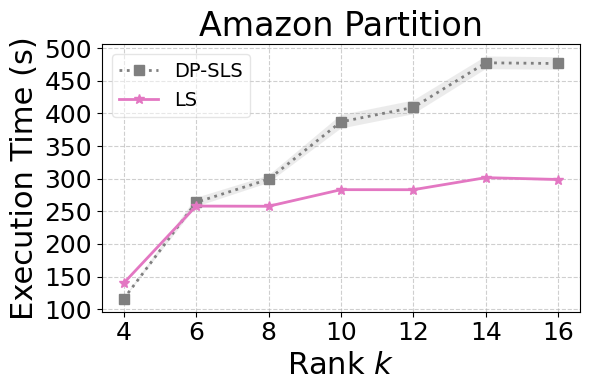

In [115]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data for eps=0.1 and lambda_param=0.1
# Using your initial filtering requirements
filtered_df = results_df[(results_df['eps'] == 0.2) & (results_df['lambda_param'] == 0.1) & ~results_df['alg'].isin(['Random'])]

# 2. Group by algorithm and 'k' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'k'])['time_sec'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with large text and distinct styles
plt.figure(figsize=(6, 4)) # Large figure size for clarity

# Define specific styles to ensure variety across algorithms
markers = ['s', '*', 'o', '^', 'o', 'x']
linestyles = [':', '-', ':', '-.', '-', '--']
colors = ['#7f7f7f','#e377c2','#17becf']

# Get the list of algorithms present in the stats
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    # Assign a unique combination of color, marker, and linestyle to each alg
    line, = plt.plot(
    alg_data['k'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
    )
    plt.fill_between(
    alg_data['k'], 
    alg_data['mean'] - alg_data['std'], 
    alg_data['mean'] + alg_data['std'], 
    color=line.get_color(),
    alpha=0.15,  # Low alpha for transparency
    edgecolor='none' # No border around the shade for a softer look
     )
    # plt.errorbar(
    #     alg_data['k'], 
    #     alg_data['mean'], 
    #     yerr=alg_data['std'], 
    #     label=alg,
    #     color=colors[i % len(colors)],
    #     marker=markers[i % len(markers)],
    #     linestyle=linestyles[i % len(linestyles)],
    #     linewidth=2.5,  # Slightly thicker lines
    #     markersize=6,  # Larger markers for better visibility
    #     capsize=6       # Distinct caps for the error bars
    # )

# Formatting for large text relative to the image size
plt.xlabel('Rank $k$', fontsize=22)
plt.ylabel('Execution Time (s)', fontsize=22)
plt.title('Amazon Partition', fontsize=24)

plt.xticks(range(4,18,2), fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5)# Legend with a box for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('amazon_matroid_k_on_time.pdf')
plt.show()

## Impact of lambda on score

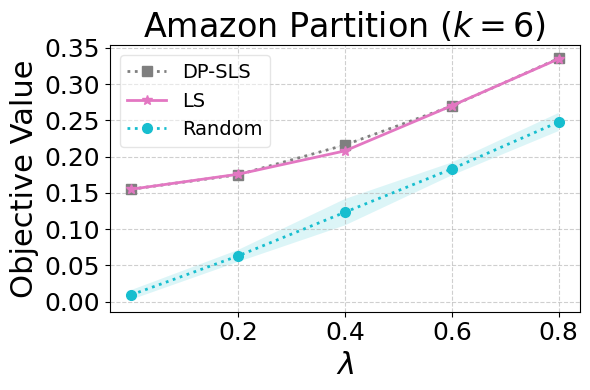

In [106]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Filter the data for k=15 and lambda_param=0.1
target_k = 6
lambda_list = [0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

filtered_df = results_df[
    (results_df['k'] == target_k) & 
    (results_df['lambda_param'].round(2).isin(lambda_list)) 
]

# 2. Group by algorithm and 'eps' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'lambda_param'])['value'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with your exact requested sizes
plt.figure(figsize=(6, 4)) # Exact size from your reference

# Define specific styles
markers = ['s', '*', 'o', '^', 'o', 'x']
linestyles = [':', '-', ':', '-.', '-', '--']
colors = ['#7f7f7f','#e377c2','#17becf']
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    # plt.errorbar(
    #     alg_data['eps'], 
    #     alg_data['mean'], 
    #     yerr=alg_data['std'], 
    #     label=alg,
    #     color=colors[i % len(colors)],
    #     marker=markers[i % len(markers)],
    #     linestyle=linestyles[i % len(linestyles)],
    #     linewidth=2.5,  
    #     markersize=6,   # Exact size from your reference
    #     capsize=6       
    # )
    line, = plt.plot(
    alg_data['lambda_param'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
    )
    plt.fill_between(
    alg_data['lambda_param'], 
    alg_data['mean'] - alg_data['std'], 
    alg_data['mean'] + alg_data['std'], 
    color=line.get_color(),
    alpha=0.15,  # Low alpha for transparency
    edgecolor='none' # No border around the shade for a softer look
     )

# Formatting with exact fontsizes from your reference
plt.xlabel('$\\lambda$', fontsize=22)
plt.ylabel('Objective Value', fontsize=22)
plt.title('Amazon Partition ($k=6$)', fontsize=24)

# Show only even ticks to avoid crowding: 0.02, 0.04, 0.06, 0.08, 0.10
plt.xticks(lambda_list[1::2], fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5)# Exact size from your reference
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() 
plt.savefig('amazon_matroid_lambda_on_val.pdf')
plt.show()

In [107]:
import pandas as pd

# Assuming your DataFrame is named 'stats'
# 1. Extract the Greedy baseline values for each lambda
greedy_baseline = stats[stats['alg'] == 'LS'][['lambda_param', 'mean']].rename(columns={'mean': 'greedy_mean'})

# 2. Merge the greedy baseline back into the stats table
df_merged = pd.merge(stats, greedy_baseline, on='lambda_param')

# 3. Calculate the percentage decrease for each row
# Formula: (Greedy_Value - Current_Value) / Greedy_Value * 100
df_merged['pct_decrease'] = (df_merged['greedy_mean'] - df_merged['mean']) / df_merged['greedy_mean'] * 100

# 4. Compute the average decrease across all lambda choices for each algorithm
final_comparison = df_merged.groupby('alg')['pct_decrease'].mean().reset_index()

# Formatting for a clean display
final_comparison.columns = ['Algorithm', 'Avg % Decrease vs Greedy']
print(final_comparison.sort_values(by='Avg % Decrease vs Greedy'))

  Algorithm  Avg % Decrease vs Greedy
0    DP-SLS                 -0.709022
1        LS                  0.000000
2    Random                 51.445735
